# Tutorial 7: Three Variables

Every tutorial so far involved exactly two variables. A third variable changes
the question you can even ask. Two processes that look tightly coupled might be
coupled directly, or might both be responding to something else entirely, and
`I(X;Y)` alone cannot tell you which. This tutorial adds a third process, `W`,
and works through the two tools that use it: conditional mutual information,
which asks what X and Y still share once W is known, and interaction
information, which asks whether a third variable makes two others look more
redundant or more synergistic.

1. Why a common driver can make two unrelated processes look coupled.
2. An oracle with three processes and exact values for every quantity used here.
3. Conditional MI, `I(X;Y|W)`, measured against its exact value.
4. Interaction information, and what its sign means.
5. A case where the sign flips: synergy, where two variables jointly determine
   a third that neither predicts alone.
6. A figure putting redundancy and synergy side by side.

## 0. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import neural_mi as nmi
from neural_mi.generators.oracle import SharedLatentGaussian

SCALE = 1

## 1. Why a Third Variable Changes Things

Two processes can be strongly correlated for very different reasons. X might
drive Y, Y might drive X, or both might be driven by something else entirely,
a third process W that neither of them controls. `I(X;Y)` cannot distinguish
these cases. A high value is consistent with all three.

Concretely: two neurons that fire together only because they share an upstream
input carry a nonzero `I(X;Y)` even if neither one influences the other at
all. The question that separates the cases is what X and Y still share once
W is already known:

$$I(X;Y|W)$$

If W is the entire explanation, conditioning on it should remove essentially
all of `I(X;Y)`. If a direct link between X and Y also exists, some of it
should survive.

That comparison, `I(X;Y)` against `I(X;Y|W)`, can be sharpened into a single
signed number: interaction information. It reports whether W matters and which
direction it pushes the relationship between X and Y, toward redundancy or
toward synergy. Both directions appear in this tutorial, on data with a known
ground truth, so the sign is checked rather than assumed.

## 2. The Oracle

`SharedLatentGaussian` takes a third entry in `dims`, conventionally called
`w`. `orc.exact` already supports a third argument, `C`, for the conditioning
set: `orc.exact(A, B)` gives `I(A;B)` and `orc.exact(A, B, C)` gives
`I(A;B|C)`. Setting `phi=0.0` removes the AR(1) correlation across time, so
every sample is drawn independently of every other sample. X, Y and W still
share information with each other at a single timestep, because all three are
noisy views of the same instantaneous latent.

In [2]:
orc = SharedLatentGaussian(dims={'x': 4, 'y': 4, 'w': 4}, d=2, phi=0.0,
                           noise=1.0, coupling=1.0, seed=0)
A, B, C = [('x', 0)], [('y', 0)], [('w', 0)]

exact = {
    'I(X;Y)':   orc.exact(A, B),
    'I(X;Y|W)': orc.exact(A, B, C),
    'I(X,W;Y)': orc.exact(A + C, B),
    'I(W;Y)':   orc.exact(C, B),
}
exact['II'] = exact['I(X,W;Y)'] - exact['I(X;Y)'] - exact['I(W;Y)']

for name, v in exact.items():
    print(f"  {name:10s} {v:9.4f} bits")

s = orc.sample(int(20000 * SCALE), seed=1)
xs, ys, ws = s['x'], s['y'], s['w']
print(f"\nshapes: x {xs.shape}, y {ys.shape}, w {ws.shape}")

  I(X;Y)        0.5328 bits
  I(X;Y|W)      0.3203 bits
  I(X,W;Y)      0.7670 bits
  I(W;Y)        0.4467 bits
  II           -0.2125 bits

shapes: x (20000, 4), y (20000, 4), w (20000, 4)


Five numbers, one relationship. `I(X;Y)` is 0.53 bits with W unseen.
Conditioning on W drops that to 0.32, so W accounts for about 0.21 of it.
`I(X,W;Y)` is 0.77 bits, well short of `I(X;Y) + I(W;Y)` = 0.98, and that
shortfall is exactly the interaction information: -0.21 bits. It is negative
because X and W's information about Y overlaps rather than adding up. That
is forced by construction here: X, Y and W are noisy readings of one shared
latent at each timestep, so anything one of them says about Y, the others
tend to say as well.

## 3. Conditional MI, Measured

The exact numbers exist because the oracle is Gaussian. On sampled data, the
same two quantities come from `nmi.run` with two different modes:
`mode='estimate'` for the unconditioned `I(X;Y)`, and `mode='conditional'` for
`I(X;Y|W)`, passing the third process through `conditional=nmi.Conditional(w_data=ws)`.

One note on the split. `Split(mode='random')` below is correct only because
`phi=0.0` made every sample independent of every other sample: there is no
time correlation for a random split to leak across. With `phi>0`, consecutive
samples correlate and the default `Split(mode='blocked')` is the one to use,
exactly as in Tutorial 3.

In [3]:
common = dict(training=nmi.Training(n_epochs=int(50 * SCALE), patience=20),
              split=nmi.Split(mode='random'), n_workers=1, seed=0, show_progress=False)

r_xy  = nmi.run(xs, ys, mode='estimate', **common)
r_cmi = nmi.run(xs, ys, mode='conditional', conditional=nmi.Conditional(w_data=ws), **common)

print(f"{'quantity':10s} {'measured':>9} {'exact':>9}")
print(f"{'I(X;Y)':10s} {r_xy.mi_estimate:9.4f} {exact['I(X;Y)']:9.4f}")
print(f"{'I(X;Y|W)':10s} {r_cmi.mi_estimate:9.4f} {exact['I(X;Y|W)']:9.4f}")

quantity    measured     exact
I(X;Y)        0.5298    0.5328
I(X;Y|W)      0.3211    0.3203


Conditioning on W removed about 0.21 bits, from 0.5298 down to 0.3211, and
that reduction matches the exact redundancy of 0.2125 to within a hundredth of
a bit. Both estimates land close to their exact counterparts: `I(X;Y)` is
about 0.6% below its exact value and `I(X;Y|W)` is about 0.25% above its
exact value. This is the payoff of doing this on an oracle first: the
estimator is not merely plausible, it is checked.

## 4. Interaction Information

There is a name for that reduction: interaction information,

$$II = I(X,W;Y) - I(X;Y) - I(W;Y)$$

It packages the joint, the pairwise, and the third-with-target information
into one number whose sign tells the story. `mode='interaction'` computes all
three pieces in a single call.

In [4]:
r_ii = nmi.run(xs, ys, mode='interaction', interaction=nmi.Interaction(w_data=ws), **common)

d = r_ii.details
print(f"I(X,W;Y) = {d['mi_xw_y']:.4f}")
print(f"I(X;Y)   = {d['mi_x_y']:.4f}")
print(f"I(W;Y)   = {d['mi_w_y']:.4f}")
print(f"II       = {d['interaction_info']:.4f}")

check = d['mi_xw_y'] - d['mi_x_y'] - d['mi_w_y']
print(f"\narithmetic: {d['mi_xw_y']:.4f} - {d['mi_x_y']:.4f} - {d['mi_w_y']:.4f} "
      f"= {check:.4f}   (reported II = {d['interaction_info']:.4f})")
print(f"exact II = {exact['II']:.4f}")

I(X,W;Y) = 0.7674
I(X;Y)   = 0.5298
I(W;Y)   = 0.4463
II       = -0.2087

arithmetic: 0.7674 - 0.5298 - 0.4463 = -0.2087   (reported II = -0.2087)
exact II = -0.2125


The arithmetic reproduces the reported value exactly, because `interaction_info`
is that subtraction applied to the three sub-estimates rather than a fourth,
independently trained critic. Measured II is -0.2087 against an exact -0.2125,
both negative.

**Negative II means redundancy.** X and W tell you overlapping things about Y:
knowing both does not add up to more than knowing either would suggest,
because part of what X says about Y, W already said. That matches the
mechanism directly: X, Y and W here are noisy views of one shared instantaneous
latent, so any pair of them is redundant with the third by construction.

The sign is not a convention to memorize and hope holds. It falls directly out
of the formula, and it is worth checking on data where the answer is known
before trusting it on data where it is not, which is exactly what Section 5
does with the opposite sign.

## 5. Synergy: The Opposite Sign

Redundancy is one direction. The other is synergy: two variables jointly
determine a third that neither predicts on its own. The canonical example is
XOR. Let X and W each be an independent fair coin, and let Y be their XOR.

Alone, X says nothing about Y: averaged over W, `Y=1` and `Y=0` are equally
likely regardless of X, so `I(X;Y) = 0` exactly, and the same holds for W.
Together, X and W determine Y exactly, so `I(X,W;Y) = 1` bit, the full entropy
of Y. Interaction information is therefore

$$II = I(X,W;Y) - I(X;Y) - I(W;Y) = 1 - 0 - 0 = +1 \text{ bit}$$

and `I(X;Y|W) = 1` bit as well, since once W is known, Y is a deterministic
function of X.

Binary values do not suit a continuous critic well, so X, W and Y are encoded
as ±1 with a small amount of Gaussian jitter, enough to make the input
continuous without blurring the two classes together.

In [5]:
T = int(20000 * SCALE)
rng = np.random.default_rng(0)
xb = rng.integers(0, 2, T)
wb = rng.integers(0, 2, T)
yb = xb ^ wb

def encode(bits, jitter=0.15):
    return (2.0 * bits - 1.0 + rng.normal(0, jitter, len(bits))).astype('float32')[:, None]

xs2, ws2, ys2 = encode(xb), encode(wb), encode(yb)   # each (T, 1)
print(f"shapes: x {xs2.shape}, w {ws2.shape}, y {ys2.shape}")
print("exact (noiseless): I(X;Y)=0, I(W;Y)=0, I(X,W;Y)=1, II=+1, I(X;Y|W)=1 bit")

xor_common = dict(model=nmi.Model(hidden_dim=64, n_layers=2),
                   training=nmi.Training(n_epochs=int(60 * SCALE), patience=25),
                   split=nmi.Split(mode='random'), n_workers=1, seed=0, show_progress=False)

r_xy2  = nmi.run(xs2, ys2, mode='estimate', **xor_common)
r_cmi2 = nmi.run(xs2, ys2, mode='conditional',
                 conditional=nmi.Conditional(w_data=ws2), **xor_common)
r_ii2  = nmi.run(xs2, ys2, mode='interaction',
                 interaction=nmi.Interaction(w_data=ws2), **xor_common)

print(f"\n{'quantity':10s} {'measured':>10} {'exact':>7}")
print(f"{'I(X;Y)':10s} {r_xy2.mi_estimate:10.6f} {0.0:7.3f}")
print(f"{'I(X;Y|W)':10s} {r_cmi2.mi_estimate:10.6f} {1.0:7.3f}")
print(f"{'II':10s} {r_ii2.mi_estimate:10.6f} {1.0:7.3f}")

shapes: x (20000, 1), w (20000, 1), y (20000, 1)
exact (noiseless): I(X;Y)=0, I(W;Y)=0, I(X,W;Y)=1, II=+1, I(X;Y|W)=1 bit



quantity     measured   exact
I(X;Y)       0.000125   0.000
I(X;Y|W)     0.999864   1.000
II           0.999739   1.000


Measured `I(X;Y)` is 0.000125 bits, indistinguishable from the exact zero.
Measured `I(X;Y|W)` is 0.999864 bits and measured II is +0.999739 bits, both
within 0.03% of the exact 1 bit.

**X alone says nothing about Y. X and W together say everything.** That is
synergy, and it mirrors Section 4's redundancy exactly: there, knowing W
duplicated what X already told you about Y; here, knowing W is what makes X
informative about Y at all. Positive II is the signature.

Nothing about the formula changed between the two cases. The same subtraction
that gave -0.21 bits on the shared-latent oracle gives +1 bit on XOR. The sign
did real work, and it did not need to be told which case it was in.

## 6. A Figure

One picture puts both cases side by side.

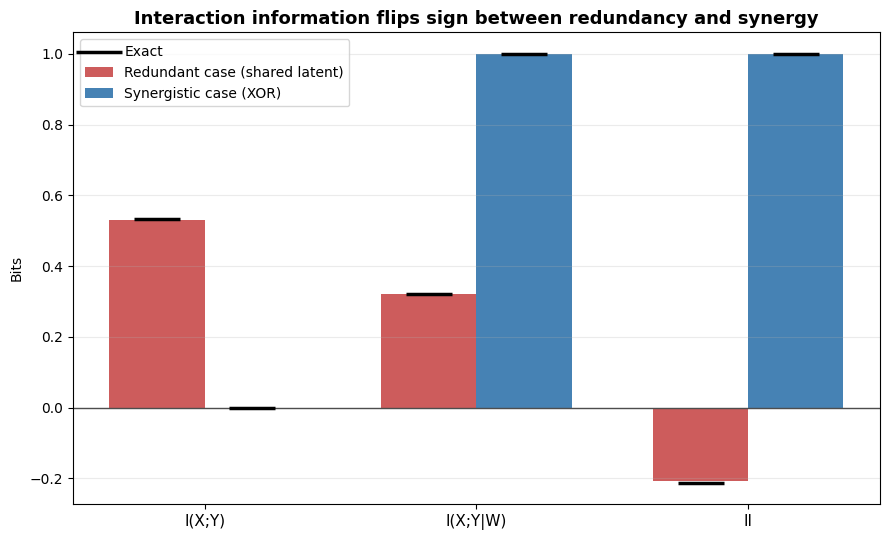

In [6]:
fig, ax = plt.subplots(figsize=(9, 5.5))

quantities = ['I(X;Y)', 'I(X;Y|W)', 'II']
redundant_est   = [r_xy.mi_estimate,  r_cmi.mi_estimate,  r_ii.mi_estimate]
redundant_exact = [exact['I(X;Y)'], exact['I(X;Y|W)'], exact['II']]
synergy_est     = [r_xy2.mi_estimate, r_cmi2.mi_estimate, r_ii2.mi_estimate]
synergy_exact   = [0.0, 1.0, 1.0]

idx = np.arange(len(quantities))
width = 0.35

ax.bar(idx - width/2, redundant_est, width, label='Redundant case (shared latent)',
       color='indianred')
ax.bar(idx + width/2, synergy_est, width, label='Synergistic case (XOR)',
       color='steelblue')

ax.scatter(idx - width/2, redundant_exact, marker='_', s=1100, linewidths=2.5,
           color='black', zorder=3, label='Exact')
ax.scatter(idx + width/2, synergy_exact, marker='_', s=1100, linewidths=2.5,
           color='black', zorder=3)

ax.axhline(0, color='0.3', lw=1)
ax.set_xticks(idx)
ax.set_xticklabels(quantities, fontsize=11)
ax.set_ylabel('Bits')
ax.set_title('Interaction information flips sign between redundancy and synergy',
             fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.25, axis='y')
plt.tight_layout()
plt.show()

The two red bars sit close to their black exact marks, and the rightmost one
sits below zero. The two blue bars sit close to their marks too, and the
rightmost one sits above zero. `I(X;Y)` is unremarkable in both cases other
than its size, near 0.53 bits on the left and near zero on the right, since X
alone is uninformative about Y in the XOR construction. `II` is the bar that
crosses zero, and it crosses because the underlying mechanism changed from
overlapping information to complementary information, not because of any
change in scale or units.

## 7. Key Takeaways

- **`I(X;Y)` alone cannot distinguish direct coupling from a shared external
  driver.** `I(X;Y|W)` can: it removed 0.21 of 0.53 bits here, matching the
  exact redundancy.

- **Interaction information packages the comparison into one signed number.**
  `II = I(X,W;Y) - I(X;Y) - I(W;Y)`, and `mode='interaction'` computes all
  three pieces and the subtraction in a single call.

- **Negative II means redundancy.** Exact -0.2125, measured -0.2087, on an
  oracle where X, Y and W are noisy views of one shared latent.

- **Positive II means synergy.** Exact +1, measured +0.9997, on XOR, where X
  and W jointly determine Y while neither predicts it alone.

- **`interaction_info` is exact arithmetic on the three sub-estimates,** not a
  fourth independently trained critic. The check in Section 4 reproduces it to
  the last printed digit.

- **`Split(mode='random')` is only valid when the data are actually IID.**
  `phi=0.0` made that true here. It would not be true for `phi>0`, where the
  default `Split(mode='blocked')` is the correct choice.

## Common Mistakes

1. **Reading a bare `I(X;Y)` as a causal or direct link** when a common driver
   W exists and was never measured. A high value is consistent with a direct
   link, a shared driver, or both.

2. **Assuming interaction information's sign convention without checking it.**
   The formula's sign falls out of the definition, not a mnemonic. This
   tutorial checked it against exact values in both directions before trusting
   it.

3. **Using `Split(mode='random')` on temporally correlated data.** It was
   correct here only because `phi=0.0`. The default `Split(mode='blocked')` is
   correct whenever samples come from a process with genuine time structure.

## What's Next

**Tutorial 9** moves from three named processes to population-scale questions:
many neurons rather than a handful, and how information changes as the
population grows.